In [2]:
# Plot ensemble mean and each ensemble member for OSDMA8

In [14]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import TwoSlopeNorm
import cartopy.crs as ccrs
from utils.utils import autosize_figure, land_filter

In [4]:
# === Concatenate ensemble members ===
def merge_ensembles(VAR_DIR, VAR, scenario, dates, start, end, time_mean=False, land_mask=False):
    """
    time_mean=True allows for time average over selected period
    land_mask=True allows for the land filter function to remove the ocean
    """
    ens = []

    for ens_num in range(1, 11):
        da = xr.open_dataarray(f"{VAR_DIR}{VAR}_CESM2_{scenario}_{ens_num:02d}_{dates}.nc").sel(year=slice(start, end))
        if time_mean is True:
            da = da.mean("year")
        ens.append(da)

    new_da = xr.concat(ens, dim=xr.DataArray(np.arange(1, len(ens)+1), dims="ensemble", name="ensemble"))

    if land_mask is True:
        print("Filtering ocean")
        new_da = land_filter(new_da)

    return new_da

In [5]:
# === Path config ===
OSDMA8_DIR = "/glade/work/awells/air_quality/CESM/ozone/OSDMA8_BC/"

# === Main loop ===
arise = merge_ensembles(OSDMA8_DIR, "OSDMA8_BC", "ARISE", "2035-2068", "2060", "2068", time_mean=True, land_mask=True)
ssp245 = merge_ensembles(OSDMA8_DIR, "OSDMA8_BC", "SSP245", "2020-2068", "2060", "2068", time_mean=True, land_mask=True)

Filtering ocean
Filtering ocean


In [6]:
difference = arise - ssp245
diff_mean = difference.mean("ensemble")

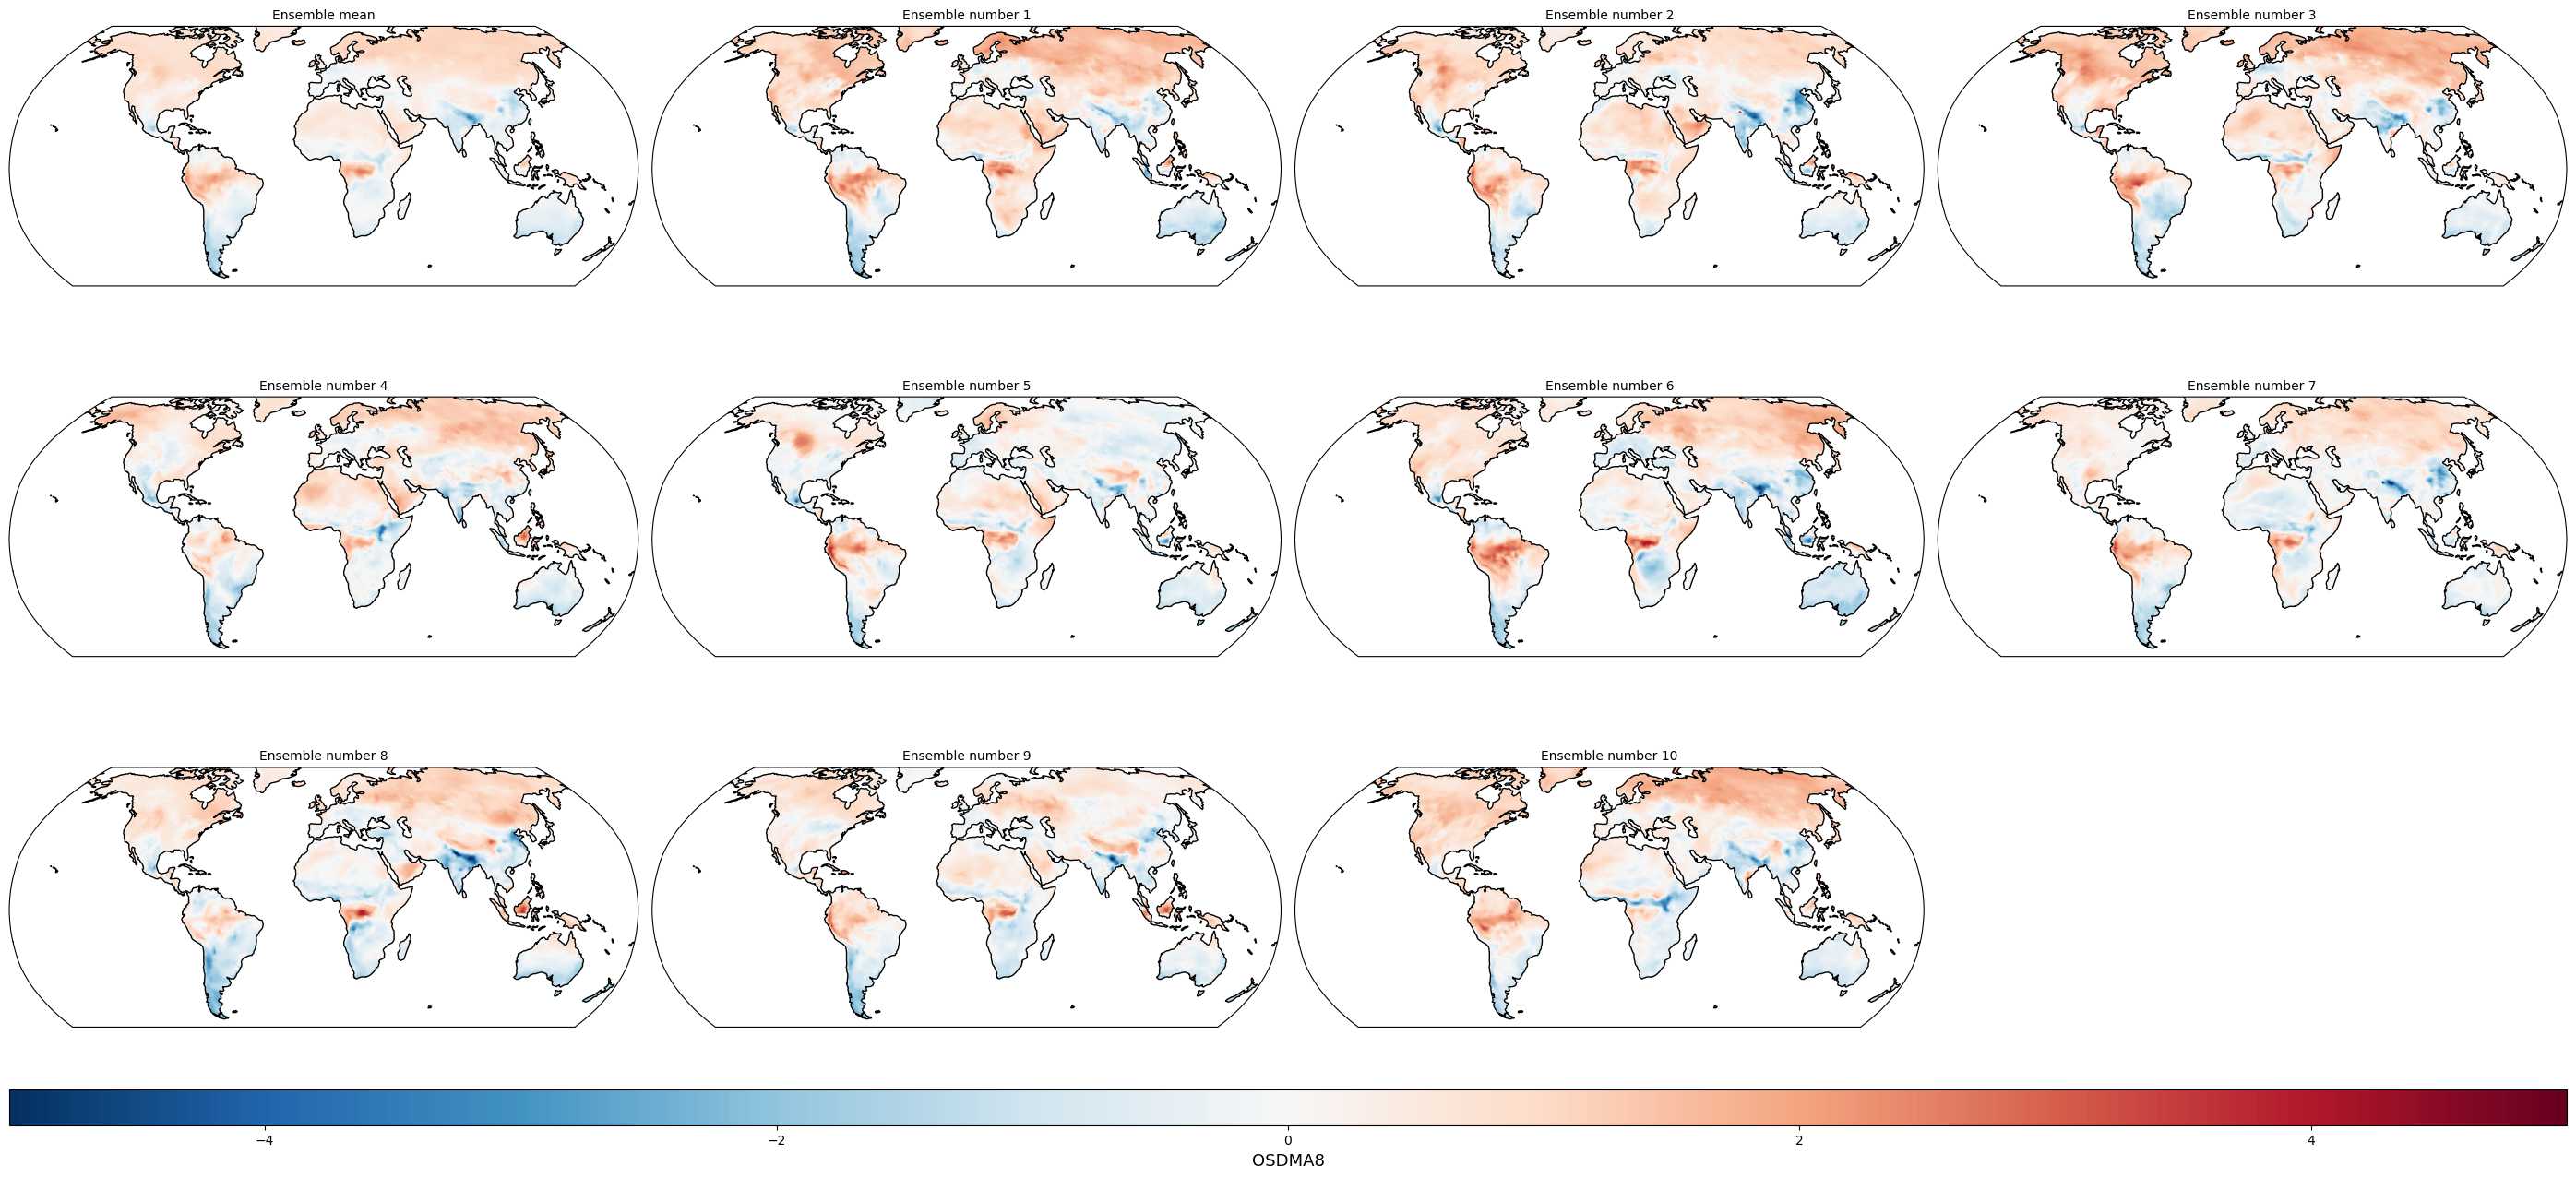

In [18]:
# Create figure
fig = plt.figure(figsize=autosize_figure(3, 4, xscale_factor=1.2))
gs = GridSpec(4, 4, height_ratios=[10, 10, 10, 1])  # rows, columns

projection = ccrs.Robinson()
crs = ccrs.PlateCarree()

cmap = "RdBu_r"

# First panel - ensemble mean
ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
cb = diff_mean.plot(
    transform=crs,
    cmap=cmap,
    vmin=-5,
    vmax=5,
    add_colorbar=False,
    subplot_kws={'projection': projection}
)
ax.coastlines()
plt.title("Ensemble mean", fontsize=10)

rows = 4
cols = 4
start_index = 1 * cols  # start from row 1 (second row)
for i in range(1, 11):
    da = difference.sel(ensemble=i)

    grid_index = i  # i starts at 1, so grid_index also starts at 1
    row = grid_index // cols
    col = grid_index % cols
    ax = fig.add_subplot(gs[row, col], projection=projection, frameon=True)
    cb = da.plot(
        transform=crs,
        cmap=cmap,
        vmin=-5,
        vmax=5,
        add_colorbar=False,
        subplot_kws={'projection': projection}
    )
    ax.coastlines()
    plt.title(f"Ensemble number {i}", fontsize=10)

cax = fig.add_subplot(gs[3, :])
col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal')
col_bar.set_label("OSDMA8", fontsize=13)

plt.tight_layout()